### Predicting Freight Cost

**Onjective:** Predict freight cost for a vendor invoice using quantity and dollars, to improve cost forecasting, budgeting, and vendor negotiation.

- Freight is a non-trivial component of landad cost.
- Poor freight estimates distort margin and inventory planning.
- Automating freight estimation helps prcurement teams forecast true cost before invoice arrival.

In [34]:
import pandas as pd 
import sqlite3
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [3]:
conn = sqlite3.connect(r"C:\Users\win\OneDrive\Desktop\ML Projects\project\data\inventory.db")
tables = pd.read_sql_query("select name from sqlite_master where type = 'table'", conn)

In [4]:
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [6]:
for table in tables['name']:
    print("Table name: ", table)
    df = pd.read_sql_query(f"select * from {table} limit 5", conn)
    display(df)

Table name:  purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table name:  purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table name:  vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table name:  begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table name:  end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
vendor_df = pd.read_sql_query("select * from vendor_invoice", conn)
vendor_df.head()

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


In [9]:
vendor_df[['Quantity', 'Freight', "Dollars"]].corr()

,Quantity,Freight,Dollars
Quantity,1.000000,0.946550,0.963831
Freight,0.946550,1.000000,0.985141
Dollars,0.963831,0.985141,1.000000


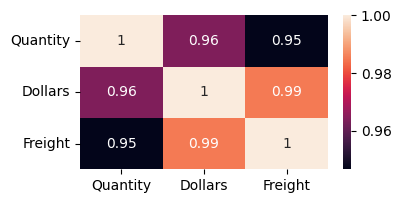

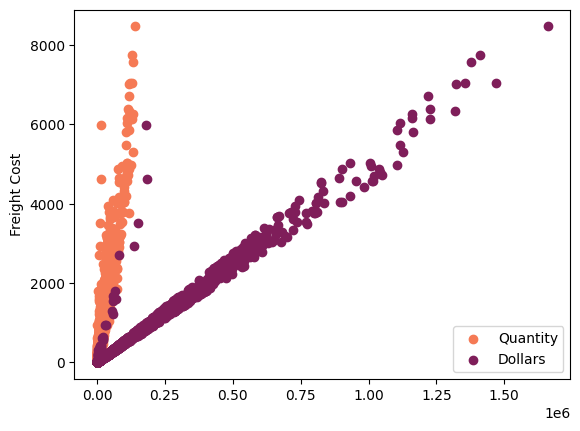

In [10]:
# Relationship between Quantity, Dollars and Freight

plt.figure(figsize=(4,2))
sns.heatmap(vendor_df[['Quantity', "Dollars", "Freight"]].corr(), annot=True)
plt.show()

plt.scatter(vendor_df["Quantity"], vendor_df["Freight"], color="#f57a55")
plt.scatter(vendor_df["Dollars"], vendor_df["Freight"], color="#7f1e5a")
plt.legend(["Quantity", "Dollars"])
plt.ylabel("Freight Cost")
plt.show()

In [11]:
vendor_df['freight_per_unit'] = vendor_df['Freight']/vendor_df['Quantity']

In [13]:
low_quantity = vendor_df['Quantity'].quantile(0.25)
high_quantity = vendor_df['Quantity'].quantile(0.75)

In [14]:
print("Hight Quntity = ",high_quantity)
print("Low Quntity = ",low_quantity)

Hight Quntity =  5100.5
Low Quntity =  83.0


In [18]:
vendor_df.loc[vendor_df['Quantity']<low_quantity, 'freight_per_unit'].mean()

np.float64(0.09489854253138316)

In [19]:
vendor_df.loc[vendor_df['Quantity']>high_quantity, 'freight_per_unit'].mean()

np.float64(0.049077654690759046)

In [38]:
X = vendor_df[['Dollars']]
y = vendor_df['Freight']

In [39]:
from sklearn.model_selection import train_test_split

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [41]:
X_test

,Dollars
4564,352.95
1616,225706.96
4861,634.11
230,987.34
2042,31768.74
...,...
3388,242.16
1321,846.99
1322,205379.19
3618,242967.77


In [55]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [56]:
model1 = LinearRegression()
model1.fit(X_train, y_train)

model2 = DecisionTreeRegressor(max_depth=5)
model2.fit(X_train, y_train)

model3 = RandomForestRegressor(max_depth=6)
model3.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [57]:
def evaluate_model(model, X_test, y_test, model_name):
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds) * 100
    
    print(f"\n{model_name} performance: ")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"r2: {r2:.2f}%")

In [58]:
evaluate_model(model1, X_test, y_test, "Linear Regression")
evaluate_model(model2, X_test, y_test, "Decision Tree Regression")
evaluate_model(model3, X_test, y_test, "Random Forest Regression")


Linear Regression performance: 
MAE: 24.11
RMSE: 124.72
r2: 96.99%

Decision Tree Regression performance: 
MAE: 32.97
RMSE: 150.31
r2: 95.63%

Random Forest Regression performance: 
MAE: 25.82
RMSE: 134.89
r2: 96.48%


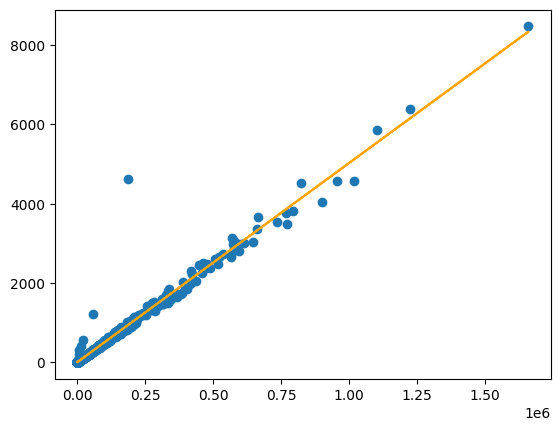

In [59]:
plt.scatter(X_test, y_test)
plt.plot(X_test, model1.predict(X_test), color='orange')
plt.show()

In [60]:
input_data = {
    "Dollars": [18500, 9000],
}

df = pd.DataFrame(input_data)

In [61]:
model1.predict(df)

array([97.78868161, 50.14455838])